In [4]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import patches 


import schemdraw
from schemdraw import flow
import schemdraw as schem
import schemdraw.elements as e
from schemdraw import dsp

%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")


Infinite Impulse Response (IIR) filters are such filters which include recursion, respectively feedback, in their implementation. Their impulse response does thus not drop to zero after a given time. They can become instable due to the feedback.
However, IIR filters require less coefficients and thus less operations to get a filter with the desired effect than FIR filters.
As FIR filters, IIR filters create an output sequence $y[n]$ from an input sequence $x[n]$:


------

# The Difference Equation

For the difference equation the recursion is included with additional coefficients $a_n$, feeding back the output signal $y[n]$ with different delays. The following difference function represents a second order IIR filter. Also referred to as *biquad filter*, this is a basic component for many digital filter implementations:

$$
y[n] = b_0 x[n] + b_1 x[n-1]+ b_2 x[n-2] - a_1 y[n-1] - a_2 y[n-2]
$$

Or short:

$$
   y[n] =  \sum\limits_{i=0}^{i=N} b_i  x[n-i] - \sum\limits_{i=1}^{i=N} a_i  y[n-i]
$$

-----

# Implementation Structure 

The above difference equation can be transferred into signal flow diagrams, called implementation structures. 
These structures can be directly implemented in actual code. 
The following one is the *direct form 1*:

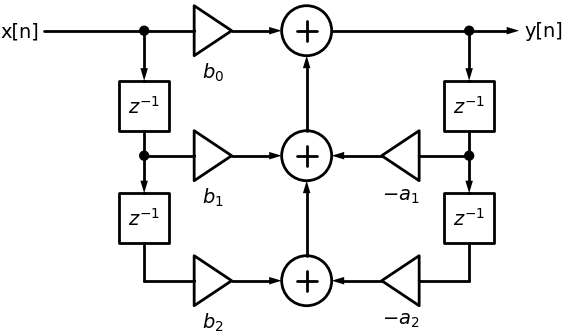

In [5]:
with schemdraw.Drawing() as d:
    d.config(unit=1, fontsize=14)
    dsp.Line().length(d.unit*2).label('x[n]', 'left').dot()

    d.push()
    dsp.Line().right()
    dsp.Amp().label('$b_0$', 'bottom')
    dsp.Arrow()
    s0 = dsp.Sum().anchor('W')
    d.pop()

    dsp.Arrow().down()
    z1 = dsp.Square(label='$z^{-1}$')
    dsp.Line().length(d.unit/2).dot()

    d.push()
    dsp.Line().right()
    dsp.Amp().label('$b_1$', 'bottom')
    dsp.Arrow()
    s1 = dsp.Sum().anchor('W')
    d.pop()

    dsp.Arrow().down(d.unit*.75)
    dsp.Square().label('$z^{-1}$')
    dsp.Line().length(d.unit*.75)
    dsp.Line().right()
    dsp.Amp().label('$b_2$', 'bottom')
    dsp.Arrow()
    s2 = dsp.Sum().anchor('W')

    dsp.Arrow().at(s2.N).toy(s1.S)
    dsp.Arrow().at(s1.N).toy(s0.S)

    dsp.Line().right(d.unit*2.75).at(s0.E).dot()
    dsp.Arrow().right().label('y[n]', 'right').hold()
    dsp.Arrow().down()
    dsp.Square().label('$z^{-1}$')
    dsp.Line().length(d.unit/2).dot()
    d.push()
    dsp.Line().left()
    a1 = dsp.Amp().label('$-a_1$', 'bottom')
    dsp.Arrow().at(a1.out).tox(s1.E)
    d.pop()

    dsp.Arrow().down(d.unit*.75)
    dsp.Square().label('$z^{-1}$')
    dsp.Line().length(d.unit*.75)
    dsp.Line().left()
    a2 = dsp.Amp().label('$-a_2$', 'bottom')
    dsp.Arrow().at(a2.out).tox(s2.E)